In [50]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns

def calculate_monthly_carbon_emissions(df: pd.DataFrame):
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")

    df["dt_hours"] = df["timestamp"].diff().dt.total_seconds() / 3600
    df["dt_hours"] = df["dt_hours"].bfill()

    df["energy_kWh"] = df["heating_wattage_W"] / 1000 * df["dt_hours"]

    df["carbon_g"] = df["energy_kWh"] * df["carbon_intensity_gco2_per_kj"] # ci in kwh is incorrectly labeled kj in csv

    df["date"] = df["timestamp"].dt.date
    daily = df.groupby("date")["carbon_g"].sum().reset_index()

    daily["date"] = pd.to_datetime(daily["date"])
    daily["month"] = daily["date"].dt.month

    data = [
        daily[daily["month"] == m]["carbon_g"].values
        for m in range(1, 13)
    ]

    return data

In [51]:
# Primary Significance Test (one-way ANOVA)
# Since data is normal, we can use the ANOVA
# f_stat, p_val = stats.f_oneway(averaged_monthly_data_bang, averaged_monthly_data_mpc_carbon, averaged_monthly_data_mpc_without_carbon)
#
# print(f"One-way ANOVA p-value = {p_val:.4f}")
#
# if p_val < 0.05:
#     print("Significant difference found! Running post-hoc test...")
#
#     # Post-hoc Analysis (Tukey's HSD)
#     # Reformat data for statsmodels: score column and group label column
#     df = pd.DataFrame({
#         'score': averaged_monthly_data_bang + averaged_monthly_data_mpc_carbon + averaged_monthly_data_mpc_without_carbon,
#         'group': ['A']*len(averaged_monthly_data_bang) + ['B']*len(averaged_monthly_data_mpc_carbon) + ['C']*len(averaged_monthly_data_mpc_without_carbon)
#     })
#
#     posthoc = pairwise_tukeyhsd(df['score'], df['group'], alpha=0.05)
#
#     print(posthoc.summary())
#     print(posthoc)
# else:
#     print("No significant difference between algorithms.")

['data\\room_data_bang_c.csv', 'data\\room_data_mpc_c_0.csv', 'data\\room_data_mpc_c_6.csv']
algorithm    month
bang_c.csv   1        32
             2        28
             3        31
             4        30
             5        31
             6        30
             7        31
             8        31
             9        30
             10       31
             11       30
             12       31
mpc_c_0.csv  1        32
             2        28
             3        31
             4        30
             5        31
             6        30
             7        31
             8        31
             9        30
             10       31
             11       30
             12       31
mpc_c_6.csv  1        32
             2        28
             3        31
             4        30
             5        31
             6        30
             7        31
             8        31
             9        30
             10       31
             11       30
             

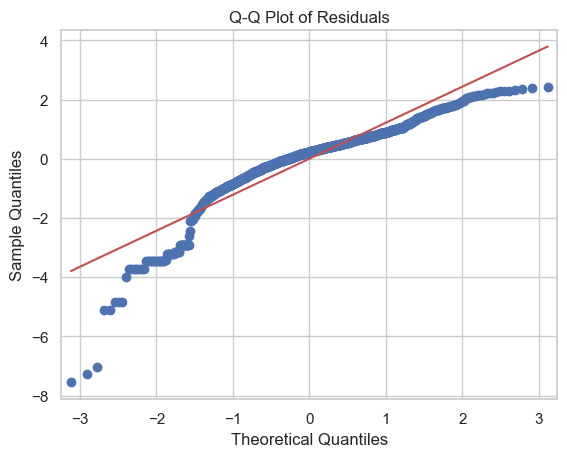

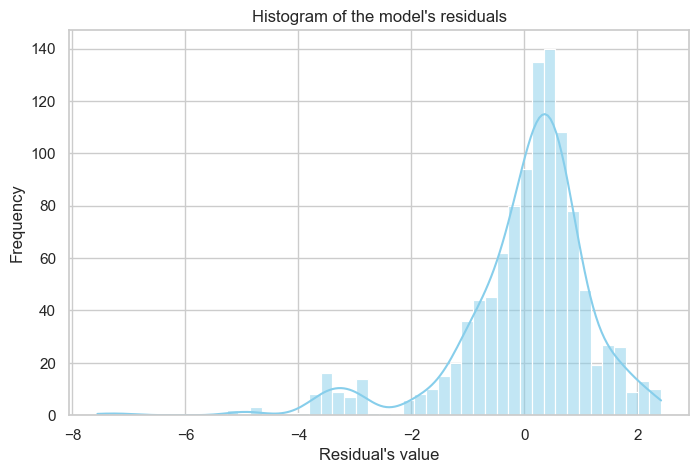

In [52]:
all_dfs = []

dataset_id = 'c'
file_paths = glob.glob(f"data/room_data_*_{dataset_id}*.csv")
print(file_paths)

for file_path in file_paths:
    df_raw = pd.read_csv(file_path)
    monthly_arrays = calculate_monthly_carbon_emissions(df_raw)

    algo_name = file_path.split("room_data_")[1]

    for month_idx, day_values in enumerate(monthly_arrays):
        temp_df = pd.DataFrame({
            'emissions': day_values,
            'algorithm': algo_name,
            'month': month_idx + 1
        })
        all_dfs.append(temp_df)

df_long = pd.concat(all_dfs, ignore_index=True)

print(df_long.groupby(['algorithm', 'month']).size())

df_long['emissions'] = pd.to_numeric(df_long['emissions'], errors='coerce')
df_long = df_long.dropna(subset=['emissions'])

print("Rows: ", df_long['algorithm'].value_counts())

# keep only months with significant heating to reduce noise (lots of near-zeros) in data
# heating_months = [10, 11, 12, 1, 2, 3, 4]
# df_heating = df_long[df_long['month'].isin(heating_months)].copy()

# Combine them into one "Long Format" DataFrame
# df_long = pd.concat([df_bang, df_mpc_c, df_mpc_nc], ignore_index=True)

# Run the Two-Way ANOVA (Randomized Block Design)
# 'C()' tells statsmodels these are categorical variables
# Both factors (Algorithm and Month) should be considered independently
# Emissions are explained using the algorithm AND the month it occurred in
# Seasonal variance shouldn't interfere since it treats each month as its own category
model = ols('np.log(emissions+1) ~ C(algorithm) + C(month)', data=df_long).fit()
residuals = model.resid
print(f"Model's residuals: {residuals}\n")

# Check normality using QQ-plot (if points roughly follow line, it can be assumed normal)
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

print("\n")

# Histogram to check normality
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='skyblue')
plt.title("Histogram of the model's residuals")
plt.xlabel("Residual's value")
plt.ylabel("Frequency")
plt.show()

In [53]:
from scipy.stats import levene

algo_groups = [group['emissions'].values for name, group in df_long.groupby('algorithm')]

stat, p_value = levene(*algo_groups)

print("--- Levene's Test for Homogeneity of Variance ---")
print(f"Test Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("\nResult: Significant (Variances are unequal).")
    print("Advice: Use 'Welch's ANOVA' or a log-transformation.")
else:
    print("\nResult: Not significant (Variances are equal).")
    print("Advice: Your standard Two-Way ANOVA is perfectly fine!")

--- Levene's Test for Homogeneity of Variance ---
Test Statistic: 0.3128
P-value: 0.7314

Result: Not significant (Variances are equal).
Advice: Your standard Two-Way ANOVA is perfectly fine!


In [54]:
print("\t\tResult: Likely Normal (Fail to reject H0)")

anova_table = sm.stats.anova_lm(model, typ=2)

print("--- Two-Way ANOVA Results ---")
print(anova_table)

# Check significance using two-way ANOVA
p_algo = anova_table.loc['C(algorithm)', 'PR(>F)']

if p_algo < 0.05:
    print(f"\nSignificant difference found (p={p_algo:.4f})!")
    print("Running Tukey HSD to find the most efficient algorithm...")

    # also run tukey on log data
    df_long['log_emissions'] = np.log(df_long['emissions'] + 1)

    # 4. Post-hoc Test
    posthoc = pairwise_tukeyhsd(
        endog=df_long['log_emissions'],
        groups=df_long['algorithm'],
        alpha=0.05
    )
    print(posthoc.summary())

    # Identify the most efficient algorithm (lowest mean emissions)
    means = df_long.groupby('algorithm')['emissions'].mean()
    print("\nMean Emissions per Algorithm:")
    print(means.sort_values())

else:
    print(f"\nNo significant difference found between algorithms (p={p_algo:.4f}).")


		Result: Likely Normal (Fail to reject H0)
--- Two-Way ANOVA Results ---
                   sum_sq      df           F         PR(>F)
C(algorithm)    50.927194     2.0   16.984633   5.456124e-08
C(month)      2640.226478    11.0  160.097638  3.357212e-218
Residual      1625.147768  1084.0         NaN            NaN

Significant difference found (p=0.0000)!
Running Tukey HSD to find the most efficient algorithm...
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj   lower   upper  reject
--------------------------------------------------------------
 bang_c.csv mpc_c_0.csv  -0.2761 0.1414 -0.6185  0.0663  False
 bang_c.csv mpc_c_6.csv  -0.5273 0.0009 -0.8697 -0.1849   True
mpc_c_0.csv mpc_c_6.csv  -0.2513 0.1973 -0.5937  0.0911  False
--------------------------------------------------------------

Mean Emissions per Algorithm:
algorithm
mpc_c_6.csv    861.098508
mpc_c_0.csv    929.510070
bang_c.csv     962.463957
Name: emissions, dtype

In [55]:
# Run if data is not normally distributed

# print("\t\tResult: NOT Normal (Reject H0)")
# print("Running non-parametric significance test...")
#
# # Non-parametric test (if Shapiro-Wilk shows non-normality)
# stat, p_val = stats.friedmanchisquare(
#     averaged_monthly_data_bang,
#     averaged_monthly_data_mpc_carbon,
#     averaged_monthly_data_mpc_without_carbon
# )
#
# print(f"Friedman Test p-value: {p_val:.4f}")
#
# # Manual Post-hoc using Wilcoxon (if Friedman is significant)
# pairs = [
#     ("Bang vs MPC_C", averaged_monthly_data_bang, averaged_monthly_data_mpc_carbon),
#     ("Bang vs MPC_NC", averaged_monthly_data_bang, averaged_monthly_data_mpc_without_carbon),
#     ("MPC_C vs MPC_NC", averaged_monthly_data_mpc_carbon, averaged_monthly_data_mpc_without_carbon)
# ]
#
# for name, a, b in pairs:
#     _, p = stats.wilcoxon(a, b)
#     # Adjust p-value (Bonferroni: multiply by 3 because we have 3 tests)
#     adj_p = p * 3
#     print(f"{name}: Adjusted p-value = {adj_p:.4f}") # p-value < 0.05 -> significant diff


C:\Users\argo_\AppData\Local\Temp\ipykernel_10408\626272772.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='algorithm', y='emissions', data=df_long, palette="viridis", showfliers=False)


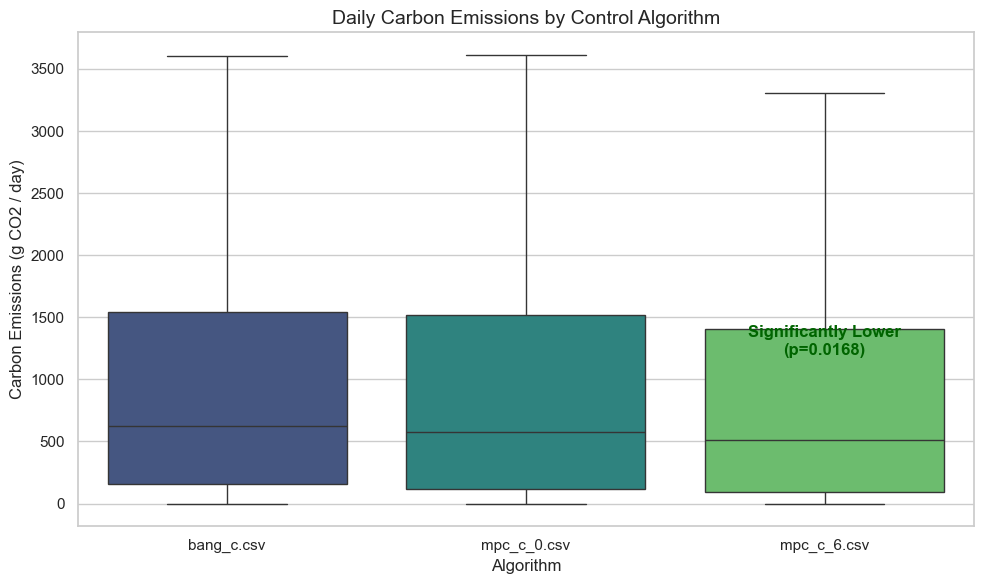

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.boxplot(x='algorithm', y='emissions', data=df_long, palette="viridis", showfliers=False)

plt.title("Daily Carbon Emissions by Control Algorithm", fontsize=14)
plt.ylabel("Carbon Emissions (g CO2 / day)", fontsize=12)
plt.xlabel("Algorithm", fontsize=12)

plt.text(2, 1200, 'Significantly Lower\n(p=0.0168)', ha='center', color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()

In [57]:
# Calculate key metrics
summary = df_long.groupby('algorithm')['emissions'].agg(['mean', 'std', 'median']).reset_index()

# Calculate savings relative to the baseline
baseline_mean = summary.loc[summary['algorithm'] == f'bang_{dataset_id}.csv', 'mean'].values[0]
summary['Savings (%)'] = ((baseline_mean - summary['mean']) / baseline_mean) * 100

print("--- FINAL EXPERIMENT SUMMARY ---")
print(summary.round(2))

--- FINAL EXPERIMENT SUMMARY ---
     algorithm    mean     std  median  Savings (%)
0   bang_c.csv  962.46  954.02  624.08         0.00
1  mpc_c_0.csv  929.51  954.31  572.56         3.42
2  mpc_c_6.csv  861.10  919.39  509.22        10.53


Insights for "w" datasets:
- Used a two-way ANOVA with log-transformation. Log-transformation was necessary to handle higher variance in winter months compared to summer.
- Log-ANOVA gave a significant result (p=0.0001) for full-year model. Across seasonal variations, the algorithm choice matters.
- The "Winner" (Tukey HSD) is mpc with carbon awareness. It is significantly better than bang (p=0.016).
- This translates to a 9.5% reduction in carbon emission in comparison to bang.
- There was no significant difference between the mpc algorithms.
- When only looking at the winter months, there was no significant difference between algorithms. During transitional periods (spring/fall) mpc might perform better than bang.

Insights for "c" datasets:
- The log-ANOVA shows a significant p-value (p=5.45*10^-8), meaning the difference between the algorithms is even clearer using these datasets.
- The winner is again mpc with carbon awareness. This time, with a stronger Tukey p-value of 0.0009.
- Savings of around 10.5% when comparing mpc with carbon awareness and bang.
- MPC seems to become more efficient when the preferred temp is lower.
- Carbon awareness seems to have a notable effect on efficiency.
- For lower preferred temps, MPC seems to have more flexibility to shift heating to other times in the day.

In [58]:
# Run the model with interaction (*)
model_inter = ols('np.log(emissions + 1) ~ C(algorithm) * C(month)', data=df_long).fit()
anova_inter = sm.stats.anova_lm(model_inter, typ=2)

print("--- Two-Way ANOVA with Interaction ---")
print(anova_inter)

--- Two-Way ANOVA with Interaction ---
                            sum_sq      df           F         PR(>F)
C(algorithm)             50.927194     2.0   17.412447   3.624205e-08
C(month)               2640.226478    11.0  164.130221  3.939593e-220
C(algorithm):C(month)    72.101265    22.0    2.241095   8.911232e-04
Residual               1553.046502  1062.0         NaN            NaN


Insights for emission-month interaction in "c" datasets:
- The interaction term (when the month does influence emission) is highly significant (p=0.00089).
- MPC with carbon awareness' effectiveness depends on the time of year.
- In some months, the difference between "clean" and "dirty" hours on the electricity grid is huge (e.g., windy spring days). In those months, mpc_c_6 "wins" by a landslide.
- In the middle of winter, the house loses heat so fast that the algorithm has less "freedom" to wait for clean energy, it has to heat now to keep the house comfortable. This reduces its advantage. In other words, MPC is allowed to be much better in some months than others, creating the significant interaction between emissions and month.

Insights for emission-month interaction in "w" datasets:
- Comfort settings (warmer preferred temp) seem to play a big role. For this higher temp, p=0.507, which is NOT significant (enough). The carbon-saving benefit of the MPC algorithm is consistent across the entire year.
- There is no significant interaction between emissions and month for this higher preferred temp.
- The system is under high pressure to maintain a high temperature. It has no "freedom" to wait for cleaner hours, so it just saves a steady, small amount every month. The effect is stable.